# Task 3: Clustering: Gaussian Mixture Models

Libraries:

In [82]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

Load data:

In [83]:
df = pd.read_csv("../data/03_selected/selected_features_with_target.csv")
df.head()

,thalach,oldpeak,ca,sex_1,cp_4,exang_1,slope_2,thal_7.0,target
0,150.0,2.3,0.0,True,False,False,False,False,0
1,108.0,1.5,3.0,True,True,True,True,False,1
2,129.0,2.6,2.0,True,True,True,True,True,1
3,187.0,3.5,0.0,True,False,False,False,False,0
4,172.0,1.4,0.0,False,False,False,False,False,0


In [84]:
X = df.drop(columns=['target'])
y_target = df['target']
X.head()

,thalach,oldpeak,ca,sex_1,cp_4,exang_1,slope_2,thal_7.0
0,150.0,2.3,0.0,True,False,False,False,False
1,108.0,1.5,3.0,True,True,True,True,False
2,129.0,2.6,2.0,True,True,True,True,True
3,187.0,3.5,0.0,True,False,False,False,False
4,172.0,1.4,0.0,False,False,False,False,False


In [85]:
scaler = StandardScaler()
X_clustering = scaler.fit_transform(X)

### 3.1 Fit GGMs with a varying number of components (2 to 10)

In [86]:
n_components_range = range(2,11)

bic_scores = []
aic_scores = []

for n_components in n_components_range:
    # Set up model
    gmm = GaussianMixture(
        n_components=n_components,
        covariance_type='full', # each cluster its own elliptical shape
        init_params='random', # initialize weights randomly (defaul = KMeans)
        random_state=42 # fix the random seed
    )

    # Fit the model
    gmm.fit(X_clustering)

    # Compute and save BIC and AIC
    bic_scores.append(gmm.bic(X_clustering))
    aic_scores.append(gmm.aic(X_clustering))

### 3.2 Use BIC or AIC to select the optimal number of components

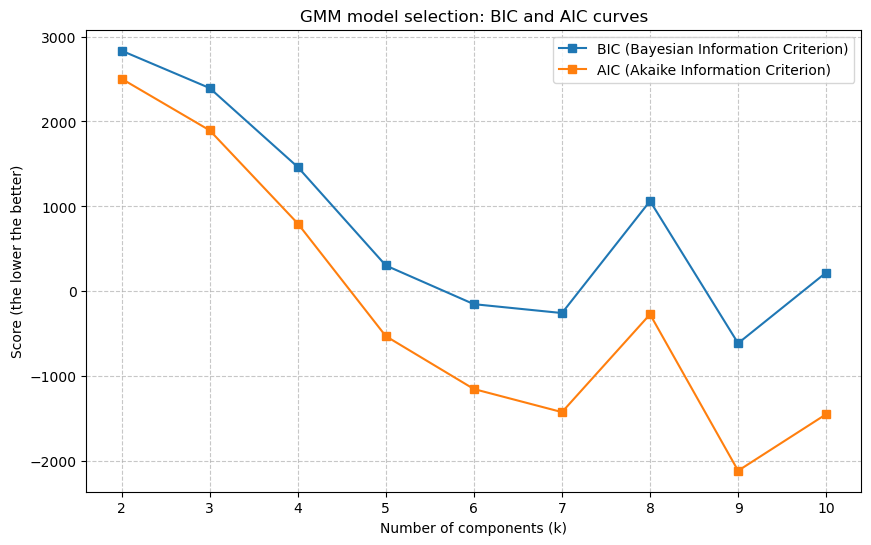

In [87]:
# Plot
plt.figure(figsize=(10,6))
plt.plot(n_components_range, bic_scores, marker = 's', label = 'BIC (Bayesian Information Criterion)')
plt.plot(n_components_range, aic_scores, marker = 's', label = 'AIC (Akaike Information Criterion)')

plt.title('GMM model selection: BIC and AIC curves')
plt.xlabel('Number of components (k)')
plt.ylabel('Score (the lower the better)')
plt.xticks(n_components_range)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### 3.3 Visualise cluster assignments by projecting the data into PCA space (2D)

PCA:

In [88]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_clustering)

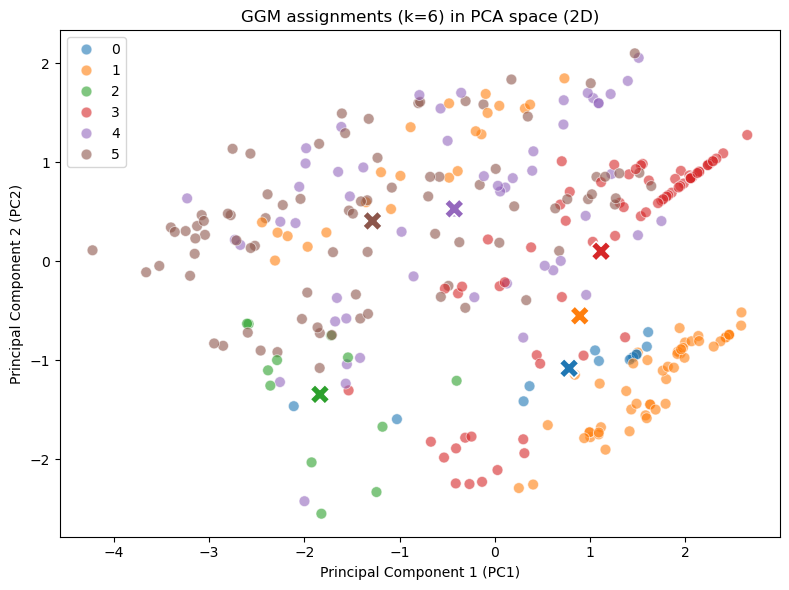

In [89]:
# Select best k and adjust the final model
best_k = 6
gmm_best = GaussianMixture(
    n_components=best_k,
    covariance_type='full',
    init_params='random',
    random_state=42
    
)
gmm_best.fit(X_clustering)
gmm_labels = gmm_best.predict(X_clustering)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=gmm_labels,
    palette='tab10',
    s=60,
    alpha=0.6
)

centroids_pca = pca.transform(gmm_best.means_)
sns.scatterplot(
    x=centroids_pca[:, 0],
    y=centroids_pca[:, 1],
    hue=range(best_k),
    palette='tab10',
    marker="X",
    s=200,
    legend=False
)

plt.title(f"GGM assignments (k={best_k}) in PCA space (2D)")
plt.xlabel("Principal Component 1 (PC1)")
plt.ylabel("Principal Component 2 (PC2)")
plt.legend()
plt.tight_layout()
plt.show()

### 3.4 Compare the hard cluster assignments from GMM with K-Means